## Draw-Tower Scheduling Across Three Hyperscalers

Three separate multibillion-dollar hyperscaler megadeals landed at Corning in 2026. Meta signed up to 6 billion dollars in January, NVIDIA committed 500 million dollars in May to help fund three new plants, and Amazon signed a multiyear, multibillion-dollar agreement in June tied to its own 10-billion-dollar North Carolina cloud buildout. Corning's CEO said plainly earlier this year, "next year the hyperscalers will be our biggest customers."

All specific numbers in the case itself are invented for practice, not Corning's real figures.

**The scenario.** One specialty draw-tower line can only be certified for one hyperscale customer's connector spec at a time this quarter, recertifying mid-quarter isn't realistic. Base capacity is 6,000 hours. Meta: 2 hours per unit, profit of 1,100 dollars per unit, demand ceiling 2,500, changeover cost of 0 dollars and 0 hours since the line is already certified for Meta's spec from last quarter. NVIDIA: 2.5 hours per unit, profit of 1,300 dollars per unit, demand ceiling 2,000, changeover cost of 180,000 dollars and 250 hours. Amazon: 1.8 hours per unit, profit of 950 dollars per unit, demand ceiling 3,000, changeover cost of 420,000 dollars and 600 hours. Goal: which single customer to dedicate the line to, and how many units to produce, to maximize profit.

No floor on any of the three, all pure ceilings, no required minimum for this quarter's dedication. Up to 800 hours of overtime can be authorized on the base capacity at an extra 150 dollars per hour. Only one customer's spec can be loaded at a time, since certifying more than one simultaneously isn't physically possible on this line.


**What we know:**

Meta:
- Resource hours: 2hr/reel
- Demand: <= 2500 reels
- Profit: 1100/reel
- Changeover hours cost: 0
- Changeover monetary cost: 0

Nvidia:
- Resource hours: 2.5hr/reel
- Demand: <= 2000 reels
- Profit: 1300/reel
- Changeover hours cost: 250 hours
- Changeover monetary cost: 180000

Amazon:
- Resource hours: 1.8hr/reel
- Demand: <= 3000 reels
- Profit: 950/reel
- Changeover hours cost: 600 hours
- Changeover monetary cost: 420000

Overtime:
- ot hours: <= 800
- ot cost: 150/hr

**Most Importantly**

Only one company (Meta, Nvidia, or Amazon) can have the draw tower this qtr

In [1]:
! pip install gurobipy

In [2]:
import gurobipy as gp
from gurobipy import GRB

mod = gp.Model("hyperscaler_scheduling")

Restricted license - for non-production use only - expires 2026-11-23


In [3]:
# decision variables
# number of units produced per company: Meta, Nvidia, Amazon
x = mod.addMVar(3,vtype='C')

# binary yes/no decision to run customer's spec
y = mod.addMVar(3,vtype='B')

# draw tower overtime hours 
e = mod.addVar(vtype='C', ub=800)

In [4]:
# objective function
mod.setObjective(1100*x[0] + 1300*x[1] + 950*x[2] - 180000*y[1] - 420000*y[2] - 150*e,sense=GRB.MAXIMIZE)

In [5]:
# constraints

# draw tower hours constraint per each unit for each customer 
draw_tower_c = mod.addConstr(2*x[0] + 2.5*x[1] + 1.8*x[2] + 250*y[1] + 600*y[2] <= 6000 + e)

# production ceilings for each company if it is decided to run their spec
meta_prod_c = mod.addConstr(x[0] <= 2500 * y[0])
mod.addConstr(x[1] <= 2000 * y[1])
mod.addConstr(x[2] <= 3000 * y[2])

# only can choose one spec due to draw tower restriction
mod.addConstr(y[0] + y[1] + y[2] <= 1)

<MConstr () *awaiting model update*>

In [6]:
mod.Params.OutputFlag = 0

In [7]:
mod.optimize()

In [8]:
mod.Status

2

In [9]:
# optimal profit this qtr given this objective function
mod.ObjVal

2750000.0

In [10]:
# quantity produced for each company: meta produced
x.X

array([2500.,    0.,    0.])

In [11]:
# yes/no decision made for each company: meta ran
y.X

array([1., 0., 0.])

In [12]:
# confirms if this resource is binding or not 
print(draw_tower_c.Slack)

1000.0


In [13]:
print(meta_prod_c.Slack)

-0.0


In [14]:
print('Meta Profit: $', mod.ObjVal)
print('Meta # of Reels: ', x[0].X)

Meta Profit: $ 2750000.0
Meta # of Reels:  2500.0


Meta was chosen over NVIDIA and Amazon, producing at its full ceiling of 2500 reels, for a quarterly profit of 2,750,000.

Only one company can occupy the draw tower for the entire quarter, but what if, hypothetically, each of the three were chosen on its own, what would that quarter's profit look like?

Before comparing the hypothetical total profit per option, each company's (Meta, Nvidia, Amazon) demand ceiling was compared against the shared 6000 hours on the draw tower to see which one was the binding constraint. Meta has 1000 hours to spare, Nvidia has 750 hours to spare, and Amazon has zero to spare. Now looking at the demands, Meta has 0 to spare, Nvidia has 0 to spare, and Amazon has 0 to spare. Therefore, the demand is the main constrained resource. In this case, each company would be happy since their demand is met. 

## Demand vs. Capacity Utilization

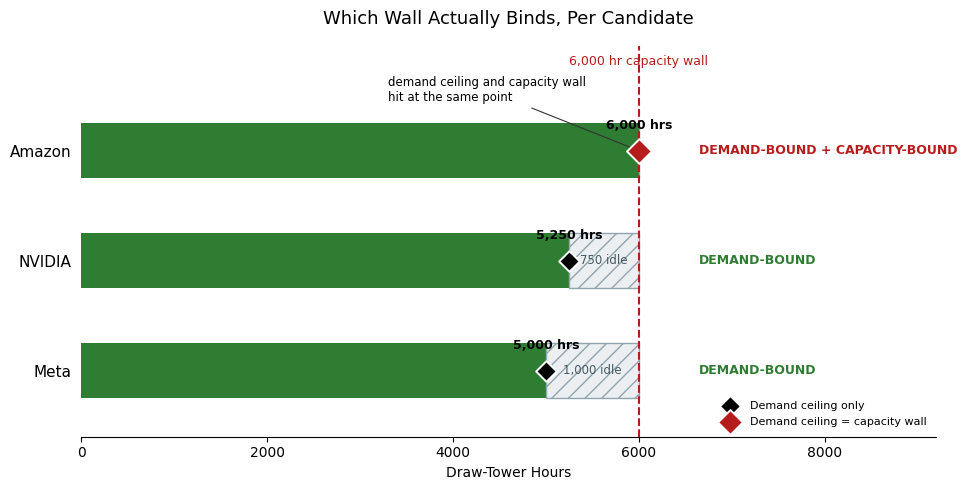

In [34]:
# import matplotlib.pyplot as plt
# import numpy as np

# companies = ['Meta', 'NVIDIA', 'Amazon']
# demand_ceiling_hrs = [5000, 5250, 6000]
# capacity = 6000
# idle_hrs = [capacity - d for d in demand_ceiling_hrs]

# fig, ax = plt.subplots(figsize=(9.5, 5))
# y_pos = np.arange(len(companies))

# ax.barh(y_pos, demand_ceiling_hrs, color='#2E7D32', height=0.5,
#         label='Hours needed at own demand ceiling', zorder=2)
# ax.barh(y_pos, idle_hrs, left=demand_ceiling_hrs, color='#ECEFF1',
#         edgecolor='#90A4AE', hatch='//', height=0.5,
#         label='Idle capacity remaining', zorder=2)

# ax.scatter(demand_ceiling_hrs, y_pos, marker='D', s=100, color='black',
#            zorder=5, label="Company's own demand ceiling")

# ax.axvline(capacity, color='#B71C1C', linestyle='--', linewidth=1.5, zorder=3)
# ax.text(capacity, 2.62, '6,000 hr capacity wall', color='#B71C1C',
#         fontsize=8.5, ha='center', va='bottom')

# ax.annotate('demand ceiling = capacity wall\n(both bind at once)',
#             xy=(6000, 2), xytext=(4300, 2.05),
#             fontsize=8.5, ha='left', va='center',
#             arrowprops=dict(arrowstyle='-', color='#333333', lw=0.8))

# ax.set_yticks(y_pos)
# ax.set_yticklabels(companies, fontsize=11)
# ax.set_xlabel('Draw-Tower Hours', fontsize=10)
# ax.set_xlim(0, 6700)
# ax.set_ylim(-0.6, 2.85)
# ax.set_title('Which Wall Actually Binds, Per Candidate', fontsize=13, pad=14)

# ax.legend(loc='upper left', bbox_to_anchor=(1.01, 0.85), fontsize=8.5, frameon=False)

# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)

# plt.tight_layout()
# plt.show()

import matplotlib.pyplot as plt
import numpy as np

companies = ['Meta', 'NVIDIA', 'Amazon']
demand_ceiling_hrs = [5000, 5250, 6000]
capacity = 6000
idle_hrs = [capacity - d for d in demand_ceiling_hrs]

# which rows ALSO hit the capacity wall (not just demand)
is_capacity_bound = [d >= capacity for d in demand_ceiling_hrs]

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(companies))

ax.barh(y_pos, demand_ceiling_hrs, color='#2E7D32', height=0.5, zorder=2)
ax.barh(y_pos, idle_hrs, left=demand_ceiling_hrs, color='#ECEFF1',
        edgecolor='#90A4AE', hatch='//', height=0.5, zorder=2)

for i, (d, ih, cap_bound) in enumerate(zip(demand_ceiling_hrs, idle_hrs, is_capacity_bound)):
    marker_color = '#B71C1C' if cap_bound else 'black'
    marker_size = 160 if cap_bound else 110

    ax.scatter(d, y_pos[i], marker='D', s=marker_size, color=marker_color,
               zorder=5, edgecolor='white', linewidth=1.4)

    ax.annotate(f'{d:,} hrs', xy=(d, y_pos[i]), xytext=(0, 16),
                textcoords='offset points', ha='center', fontsize=9,
                fontweight='bold', zorder=6)

    if ih > 200:
        ax.text(d + ih / 2, y_pos[i], f'{ih:,} idle', ha='center', va='center',
                fontsize=8.5, color='#455A64', zorder=6)

    if cap_bound:
        tag, tag_color = 'DEMAND-BOUND + CAPACITY-BOUND', '#B71C1C'
    else:
        tag, tag_color = 'DEMAND-BOUND', '#2E7D32'
    ax.text(6650, y_pos[i], tag, ha='left', va='center',
            fontsize=9, fontweight='bold', color=tag_color)

ax.axvline(capacity, color='#B71C1C', linestyle='--', linewidth=1.5, zorder=3)
ax.text(capacity, 2.75, '6,000 hr capacity wall', color='#B71C1C',
        fontsize=9, ha='center', va='bottom')

for i, cap_bound in enumerate(is_capacity_bound):
    if cap_bound:
        ax.annotate('demand ceiling and capacity wall\nhit at the same point',
                    xy=(capacity, y_pos[i]), xytext=(capacity - 2700, y_pos[i] + 0.55),
                    fontsize=8.5, ha='left', va='center',
                    arrowprops=dict(arrowstyle='-', color='#333333', lw=0.8))

ax.set_yticks(y_pos)
ax.set_yticklabels(companies, fontsize=11)
ax.set_xlabel('Draw-Tower Hours', fontsize=10)
ax.set_xlim(0, 9200)
ax.set_ylim(-0.6, 2.95)
ax.set_title('Which Wall Actually Binds, Per Candidate', fontsize=13, pad=16)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)

ax.scatter([], [], marker='D', s=110, color='black', edgecolor='white',
           linewidth=1.2, label='Demand ceiling only')
ax.scatter([], [], marker='D', s=160, color='#B71C1C', edgecolor='white',
           linewidth=1.4, label='Demand ceiling = capacity wall')
ax.legend(loc='lower right', fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

## Segment Margin Comparison

Meta = 2500 * 1100 - 0 = 2,750,000

Nvidia = 2000 * 1300 - 180000 = 2,420,000

Amazon = 3000 * 950 - 420000 = 2,430,000

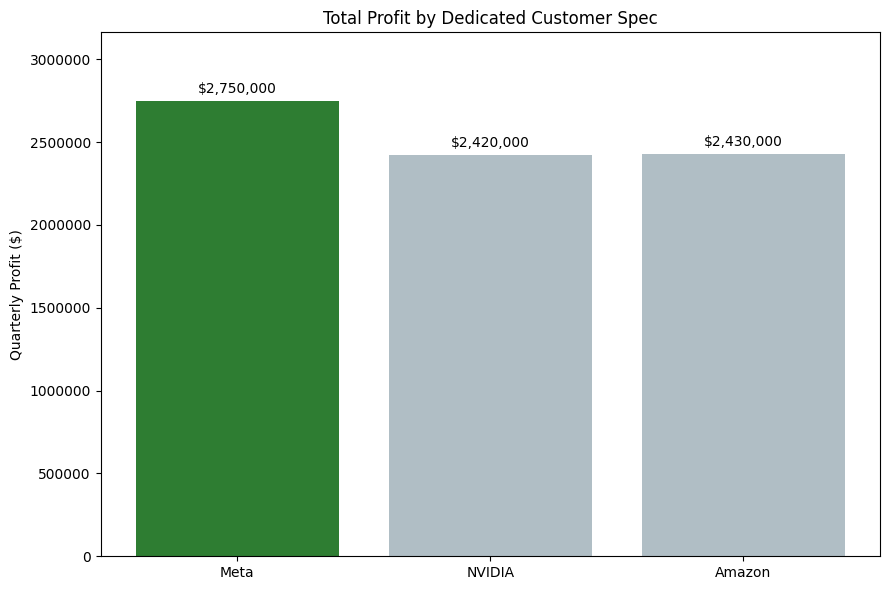

In [16]:
import matplotlib.pyplot as plt

companies = ['Meta', 'NVIDIA', 'Amazon']
total_profit = [2750000, 2420000, 2430000]
colors = ['#2E7D32', '#B0BEC5', '#B0BEC5']

plt.figure(figsize=(9, 6))
bars = plt.bar(companies, total_profit, color=colors)
plt.ylabel('Quarterly Profit ($)')
plt.title('Total Profit by Dedicated Customer Spec')
plt.ticklabel_format(style='plain', axis='y')

# add the value label above each bar
for bar, value in zip(bars, total_profit):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
              f'${value:,.0f}', ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(total_profit) * 1.15)  # extra headroom so labels don't get cut off
plt.tight_layout()
plt.show()

## Monte Carlo Style Simulation

In [17]:
import numpy as np
np.random.seed(1)

In [18]:
# quantity of interest: how often meta remains the best choice? what does meta's profit look like?

In [19]:
# fixed historical record, last 5 quarters, already happened, not random 
# past quartery reports should highlight this information:
# if not, need to do digging or model off a normal distribution

meta_historical_demand = [2340, 2610, 2480, 2550, 2290]
nvidia_historical_demand = [1890, 2050, 1920, 2140, 1980]
amazon_historical_demand = [3120, 2860, 3050, 2940, 3180]

meta_historical_hrs = [2.05, 1.95, 2.10, 1.98, 2.02]
nvidia_historical_hrs = [2.55, 2.43, 2.61, 2.48, 2.53]
amazon_historical_hrs = [1.85, 1.76, 1.82, 1.79, 1.88]

In [20]:
# averaging and std for historical demand for assumption parameters 
meta_d_mean = np.mean(meta_historical_demand)
meta_d_std = np.std(meta_historical_demand, ddof=1)

nvidia_d_mean = np.mean(nvidia_historical_demand)
nvidia_d_std = np.std(nvidia_historical_demand, ddof=1)

amazon_d_mean = np.mean(amazon_historical_demand)
amazon_d_std = np.std(amazon_historical_demand, ddof=1)

In [21]:
# averaging and std for historical machine hours for assumption parameters 
meta_h_mean = np.mean(meta_historical_hrs)
meta_h_std = np.std(meta_historical_hrs, ddof=1)

nvidia_h_mean = np.mean(nvidia_historical_hrs)
nvidia_h_std = np.std(nvidia_historical_hrs, ddof=1)

amazon_h_mean = np.mean(amazon_historical_hrs)
amazon_h_std = np.std(amazon_historical_hrs, ddof=1)

In [22]:
# "mean/std = how many standard deviations separate the average from zero. 
# Large ratio (Meta's is 18), negative draws basically never happen. 
# Ratio near or below 1, negative draws become common, and that's exactly 
# when clamping starts meaningfully distorting the distribution instead of 
# just being a safety net that never fires."

capacity = 6000
# $150/hr of overtime for draw tower
overtime_rate = 150
# max overtime hours for draw tower 
overtime_cap = 800

def units_and_ot_cost(demand, hrs_per_unit, changeover_hrs, profit_per_unit):
    
    # what you can produce with no overtime and base 6000 hours
    base_hrs = capacity - changeover_hrs
    units_no_ot = min(demand, base_hrs / hrs_per_unit)

    # does this company's profit/hr beats what OT costs
    profit_per_hr = profit_per_unit / hrs_per_unit
    if profit_per_hr <= overtime_rate:
        return units_no_ot, 0.0

    hrs_available_with_ot = capacity + overtime_cap - changeover_hrs
    # either demand is hit first or you can't fulfill demand even with overtime exercised
    # client unhappy if demand is not met, even if overtime is in place
    units_with_ot = min(demand, hrs_available_with_ot / hrs_per_unit)
    extra_units = units_with_ot - units_no_ot
    ot_cost = extra_units * hrs_per_unit * overtime_rate
    return units_with_ot, ot_cost
    

def run_one_simulation():
    # generate one random demand for next qtr for each company 
    # centered based on the historical avg, spread based on historical variability
    meta_demand = max(0, np.random.normal(meta_d_mean, meta_d_std))
    nvidia_demand = max(0, np.random.normal(nvidia_d_mean, nvidia_d_std))
    amazon_demand = max(0, np.random.normal(amazon_d_mean, amazon_d_std))

    # same idea for hrs per unit
    meta_hrs = max(0, np.random.normal(meta_h_mean, meta_h_std))
    nvidia_hrs = max(0, np.random.normal(nvidia_h_mean, nvidia_h_std))
    amazon_hrs = max(0, np.random.normal(amazon_h_mean, amazon_h_std))

    # can't produce more than demand allows or the tower allows 
    # bakes the draw tower hrs constraint and demand constraints
    # units are basically constrained by demand or constrained by capacity 

    # overtime-aware units AND the cost of whatever overtime it used 
    meta_units, meta_ot_cost = units_and_ot_cost(meta_demand, meta_hrs, 0, 1100)
    nvidia_units, nvidia_ot_cost = units_and_ot_cost(nvidia_demand, nvidia_hrs, 250, 1300)
    amazon_units, amazon_ot_cost = units_and_ot_cost(amazon_demand, amazon_hrs, 600, 950)

    meta_profit = meta_units*1100 - meta_ot_cost
    nvidia_profit = nvidia_units*1300 - 180000 - nvidia_ot_cost
    amazon_profit = amazon_units*950 - 420000 - amazon_ot_cost

    
    return meta_profit, nvidia_profit, amazon_profit 

In [35]:
# number of simulations per batch
nsim = 2000
# number of batches
nbatch = 5

meta_batch_winrates, nvidia_batch_winrates, amazon_batch_winrates = [], [], []
meta_batch_profits, nvidia_batch_profits, amazon_batch_profits = [], [], []

# collect every single simulated quarter's profit, unaveraged
meta_all_profits, nvidia_all_profits, amazon_all_profits = [], [], [] 

for b in range(nbatch):
    results = np.array([run_one_simulation() for _ in range(nsim)])
    winners = np.argmax(results, axis=1)

    meta_batch_winrates.append(np.mean(winners == 0))
    nvidia_batch_winrates.append(np.mean(winners == 1))
    amazon_batch_winrates.append(np.mean(winners == 2))
    
    meta_batch_profits.append(np.mean(results[:,0]))
    nvidia_batch_profits.append(np.mean(results[:,1]))
    amazon_batch_profits.append(np.mean(results[:,2]))

    meta_all_profits.extend(results[:,0])
    nvidia_all_profits.extend(results[:,1])
    amazon_all_profits.extend(results[:,2])

In [38]:
companies = [
    ('Meta', meta_batch_winrates, meta_batch_profits, meta_all_profits),
    ('NVIDIA', nvidia_batch_winrates, nvidia_batch_profits, nvidia_all_profits),
    ('Amazon', amazon_batch_winrates, amazon_batch_profits, amazon_all_profits),
]

for name, wr_list, profit_list, all_profits in companies:
    win_rate = np.mean(wr_list) * 100
    win_rate_std = np.std(wr_list, ddof=1) * 100

    profit_mean = np.mean(profit_list)
    profit_std_raw = np.std(all_profits, ddof=1)

    print(name)
    print('  win-rate:', round(win_rate, 1), '%')
    print('  win-rate std err:', round(win_rate_std, 2), '%')
    print('  mean profit: $', round(profit_mean))
    print('  profit std (per-quarter swing): $', round(profit_std_raw))
    print()

Meta
  win-rate: 88.9 %
  win-rate std err: 0.51 %
  mean profit: $ 2702617
  profit std (per-quarter swing): $ 149645

NVIDIA
  win-rate: 6.2 %
  win-rate std err: 0.45 %
  mean profit: $ 2414815
  profit std (per-quarter swing): $ 131986

Amazon
  win-rate: 4.9 %
  win-rate std err: 0.57 %
  mean profit: $ 2433140
  profit std (per-quarter swing): $ 100191



now need to understand what does a high standard error look like, how to tune n to get the robustness we want, after we get the n we want what does it even mean



## Discrete Event Simulation 

In [25]:
!pip install simpy

In [26]:
import simpy

In [27]:
# defines what happens to a single unit, from when it arrives to departs the system
def process_unit(env, tower, results, hrs_mean, hrs_std):
    
    # time it arrives in the system
    arrival_time = env.now
    
    # asking/calling for the tower
    with tower.request() as req:
        # wait till the tower is available
        # once free, records how long a reel waits
        yield req
        results['wait_times'].append(env.now - arrival_time)

        # time when processing begins
        # uses historical hrs averages and variance to determine how long service takes
        service_start = env.now
        yield env.timeout(max(0.1, np.random.normal(hrs_mean, hrs_std)))

        # running tab of how long service takes (how long resource is physically occupied)
        # log the total time in system and log in the counter
        results['busy_time'] += env.now - service_start
        results['time_in_system'].append(env.now - arrival_time)
        results['completed'] += 1

In [28]:
# process for generating new reels(units) for as long as the simulation occurs
def unit_arrivals(env, tower, results, mean_interarrival, hrs_mean, hrs_std):
    # runs until we stop the sim
    while True:
        # wait a random gap until the next reel shows up 
        # the time between when one arrives and the next arrives 
        yield env.timeout(np.random.exponential(mean_interarrival))

        # processes the schedule we defined earlier
        env.process(process_unit(env, tower, results, hrs_mean, hrs_std))

In [29]:
# sets how many hours make up one full simulated quarter
SIM_DURATION = 6000

# the time between when one arrives and the next arrives
mean_interarrival = SIM_DURATION / meta_d_mean

# creates a brand new independent simulation clock for this run
env = simpy.Environment()

# create the shared resource, 1 runs at a time
tower = simpy.Resource(env, capacity=1)

# empty dict to stor everything this run needs to measure
results = {'completed':0, 'wait_times': [], 'busy_time': 0.0, 'time_in_system': []}

# schedules the arrival process to begin, using Meta's own historical data 
env.process(unit_arrivals(env, tower, results, mean_interarrival, meta_h_mean, meta_h_std))

# start the sim clock until it reaches end of duration
env.run(until=SIM_DURATION)

In [30]:
# how many reels completed per draw tower hour, lambda in Little's law 
throughput = results['completed'] / SIM_DURATION

# averages every recorded wait time across all reels processed this run
avg_wait_time = np.mean(results['wait_times'])

# the percentage of the qtr the draw tower was occupied processing a unit/reel
utilization = results['busy_time'] / SIM_DURATION

avg_service_time = results['busy_time'] / results['completed']

# averages arrival-to-departure time across all reels, W in Litle's law 
avg_time_in_system = np.mean(results['time_in_system'])

# how many reels in the system at a given moment, L in Little's law
work_in_process = throughput * avg_time_in_system

In [31]:
print('completed:', results['completed'])
print('throughput/hr:', round(throughput, 3))
print('\n')
print('avg wait:', round(avg_wait_time, 2))
print('avg service time per unit:', round(avg_service_time, 3))
print('avg time in system per unit:', round(avg_time_in_system, 3))
print('\n')
print('utilization:', round(utilization, 3))

print('Littles Law predicted WIP:', round(work_in_process, 2))
print('average meta demand:', meta_d_mean)

completed: 2520
throughput/hr: 0.42


avg wait: 5.09
avg service time per unit: 2.018
avg time in system per unit: 7.106


utilization: 0.847
Littles Law predicted WIP: 2.98
average meta demand: 2454.0


after running this single qtr simulation, the demand is met and exceeded. If you map this to the MIP, this simulation shows that the demand is the binding constraint rather than the draw tower hours since its utilization is at 83.4% very close to what we calculated in the MIP 83.3%. Now, this brings up the question, if the company could afford to take on smaller clients or a client with the same spec as meta to try to improve the utilization. Make sure to keep cushion between the max draw tower hours, maybe 5% for protection if delays, maintenance, or any disruptions occur. Right now we have 16.6% of unused processing hours, how can we make it to where its close to 5%?

bursty, unpredictable arrivals meeting a service process with almost no flexibility to catch up is what generates the backlog, as well as the built-in bottleneck of 1 draw tower